In [1]:
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/GTeX_experiment/42_variants.csv")

<Figure size 600x4300 with 0 Axes>

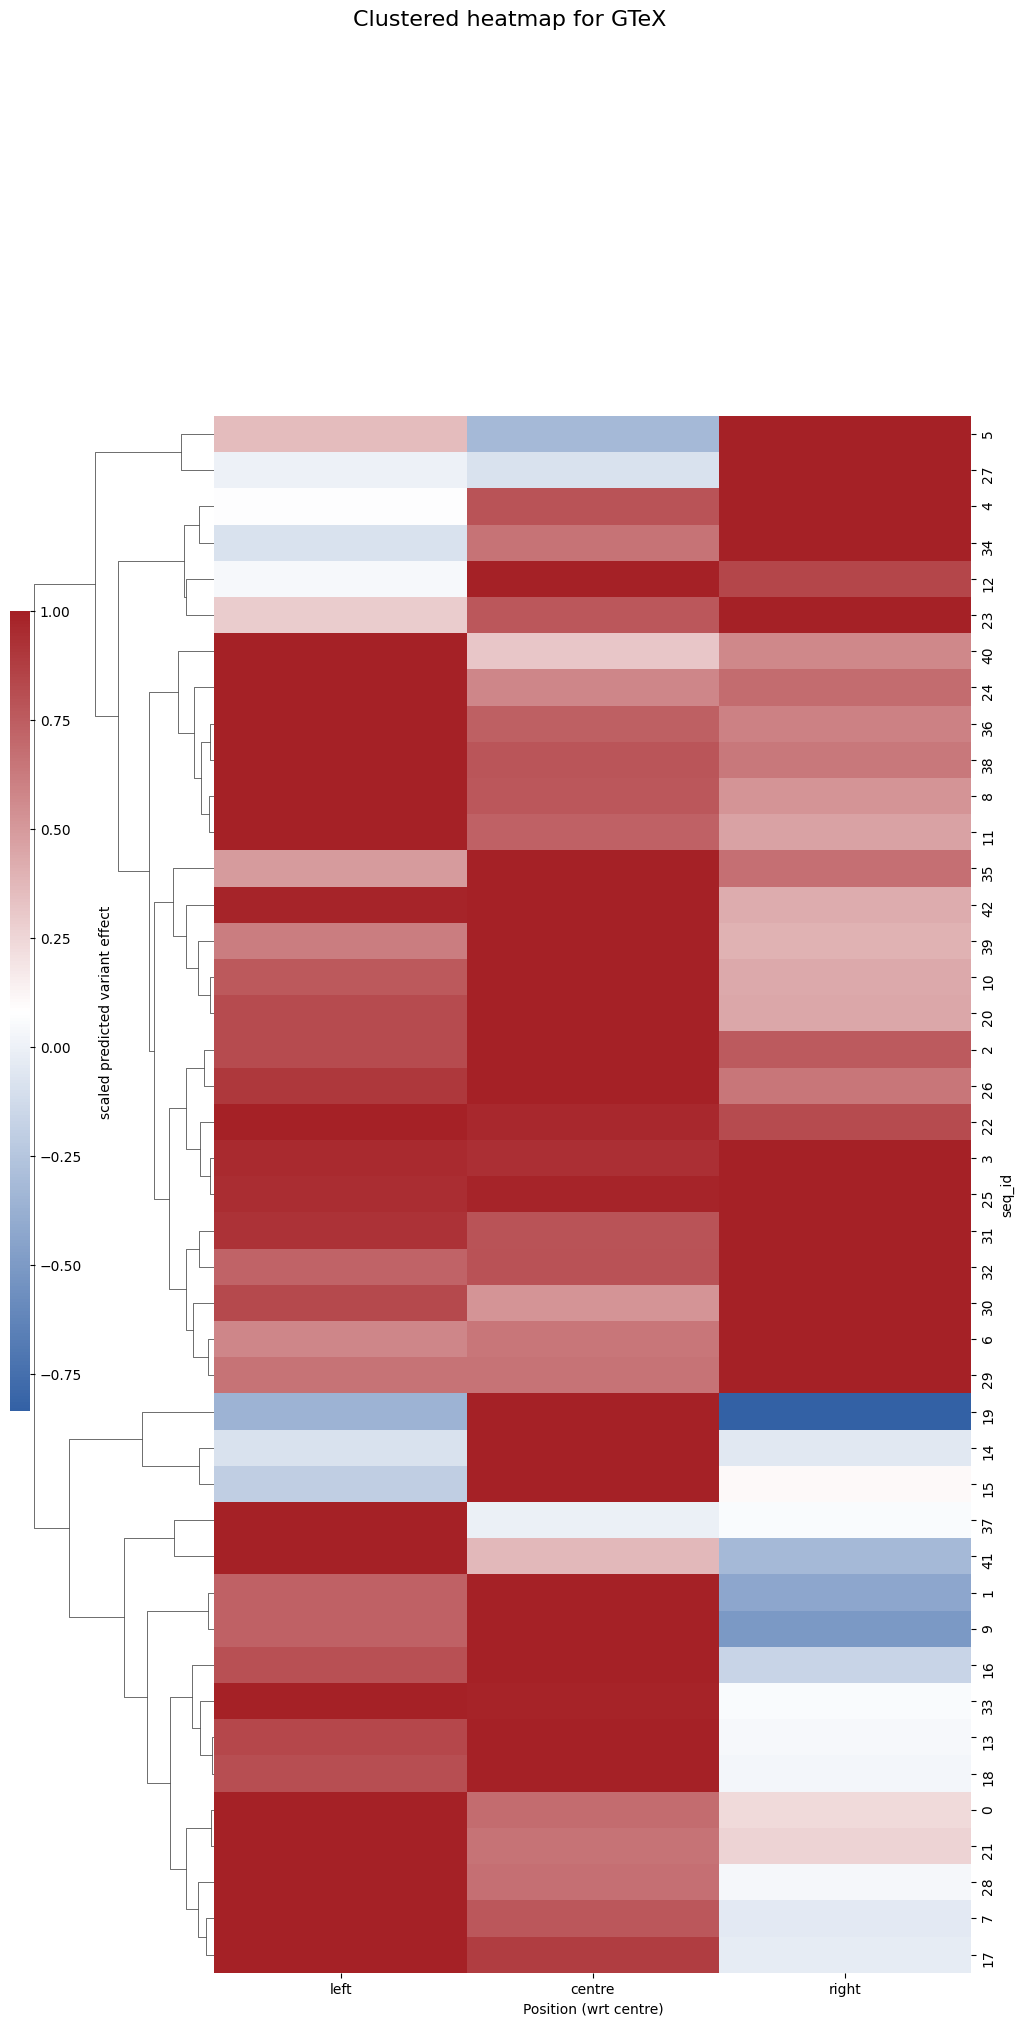

In [2]:
heatmap_data = df[['left', 'centre', 'right']]
heatmap_data = heatmap_data.apply(lambda row: row / row.loc[row.abs().idxmax()], axis=1)


# Plot the heatmap
plt.figure(figsize=(6, len(df)))  


colors = ['#3361A5', '#ffffff', '#A52126']

cmap = LinearSegmentedColormap.from_list('custom_red_black_blue', colors, N=256)

g = sns.clustermap(
    heatmap_data,    
    cmap=cmap,
    metric='euclidean', 
    method='complete',
    figsize=(10,20),
    annot=False,           
    col_cluster=False,    
    z_score=None,
    standard_scale=None
)

g.cax.set_position([0, .3, .02, .4])
g.cax.set_ylabel("scaled predicted variant effect", rotation=90, labelpad=12)

g.ax_heatmap.set_xlabel("Position (wrt centre)")
g.ax_heatmap.set_ylabel("seq_id")
g.fig.suptitle("Clustered heatmap for GTeX", y=1.001, fontsize=16, ha='center')
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/heatmap_GTEX.svg", format="svg")

plt.show()
